In [1]:
import numpy as np
np.seterr(invalid='ignore', divide='ignore')
from matplotlib import pyplot as plt
from matplotlib import colors

from numpy.random import rand
from scipy.stats import truncexpon

from neutronMS import *

In [2]:
SMALL_SIZE = 20
MEDIUM_SIZE = 20
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Monte carlo simulation of inelastic multiple scattering

# Variables for simulation

## Geometry
The experimental geometry, i.e. the sample shape (within the cell): could be a cylinder, a cuboid or an anular cll.)

In [3]:
#####################
###### Geometry #####
#####################
geom = ('cylinder', 1.2, 3) # r, h
#geom = ('cuboid', .1, 10, 10) # dx, dy, dz
#geom = ('anular', 1.0, 1.2, 2) # r1, r2, h

### Experiment geometry ###
x_init = -100 #cm

### "detector" apertures
dOmega_det = 4*np.pi/10000
domega_det = .01

In [4]:
if geom[0]=='cuboid':
    geom_type = 'convex'
    ngen = lambda N: ngen4Cub(geom, x_init, N)
    inter_fromout, inter_fromin = lambda p, v: CubLine_inter_fromout(geom, p, v), lambda p, v: CubLine_inter_fromin (geom, p, v)
elif geom[0]=='cylinder':
    geom_type = 'convex'
    ngen = lambda N: ngen4Cyl(geom, x_init, N)
    inter_fromout, inter_fromin = lambda p, v: CylLine_inter_fromout(geom, p, v), lambda p, v: CylLine_inter_fromin (geom, p, v)
elif geom[0]=='anular':
    geom_type = 'concave'
    ngen = lambda N: ngen4Anu(geom, x_init, N)
    inter_fromout, inter_fromin = lambda p, v: AnuLine_inter_fromout(geom, p, v), lambda p, v: AnuLine_inter_fromin (geom, p, v)

## Scattering geometry
Here we define the scattering geometry: the initial and final energy of the neutron, and the scattering angle.

In [5]:
####################################
##### Scattering configuration #####
####################################

### Incident energy ###
ki = 6.4 #A^-1

### Final energy ###
kf = 4.9 #A^-1

### Scattering angle###
theta = np.deg2rad(1)

### Othr parameters ###
Ei = k2E(ki) #meV
Ef = k2E(kf)
omega = Ei - Ef
Q = theta2Q(omega, ki, theta)

In [6]:
print('ki = ', ki, 'A^-1')
print('kf = ', kf, 'A^-1')
print('theta = ', np.rad2deg(theta), 'deg')
print('Ei = ', Ei, 'meV')
print('Ef = ', Ef, 'meV')

print('omega = ', omega, 'meV')
print('Q = ', Q, 'A^-1')

ki =  6.4 A^-1
kf =  4.9 A^-1
theta =  1.0 deg
Ei =  84.86986569669868 meV
Ef =  49.74915711371425 meV
omega =  35.120708582984435 meV
Q =  1.5031808140709941 A^-1


## Scattering lenghts

In [7]:
##############################
##### Scattering lenghts #####
##############################
mu_s = .6 #cm^-1
mu_abs = 0.2 #cm^-1
mu_tot = mu_s + mu_abs

## Lamber-Beer law

In [96]:
###########################
##### Lamber-Beer law #####
###########################

# Trasmission
T_tot = lambda d: np.exp(-mu_tot*d)

# Random scattering extraction from Lamber-Beer law
rand_LB = lambda b: truncexpon.rvs(b = b*mu_tot)/mu_tot

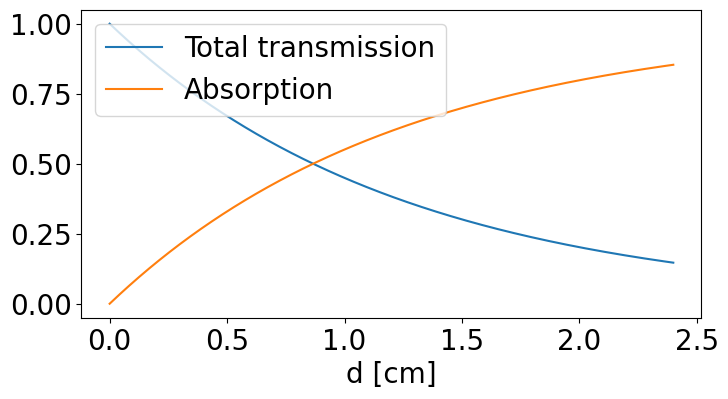

In [97]:
# plot
X = np.linspace(0, 2.4, 1000)
Y = T_tot(X)

plt.figure(figsize=(8,4))
plt.plot(X,Y, label='Total transmission')
plt.plot(X, 1-Y, label='Absorption')
plt.xlabel('d [cm]')

plt.legend();

# The Calculation

In [8]:
###############################
##### # of Montecrlo reps #####
###############################
N=10000

## Initial coordinates
$$
\textbf{p}_0 = (x_0, \ \text{rand } y_0, \ \text{rand } z_0) \hspace{1cm}    \textbf{k}_0 = (k_i, 0, 0) \hspace{1cm} \omega_0=1
$$

In [9]:
##########################
##### THE SIMULATION #####
##########################

##### RANDOMLY GENERATE N NEUTRONS #####
# from uniform beam at x=-x_init, random z = [-h/2, h/2] and y[-r, r]
p0 = ngen(N)
k0 = np.array([[ki, 0, 0]]*N)
w0 = np.array([1]*N)

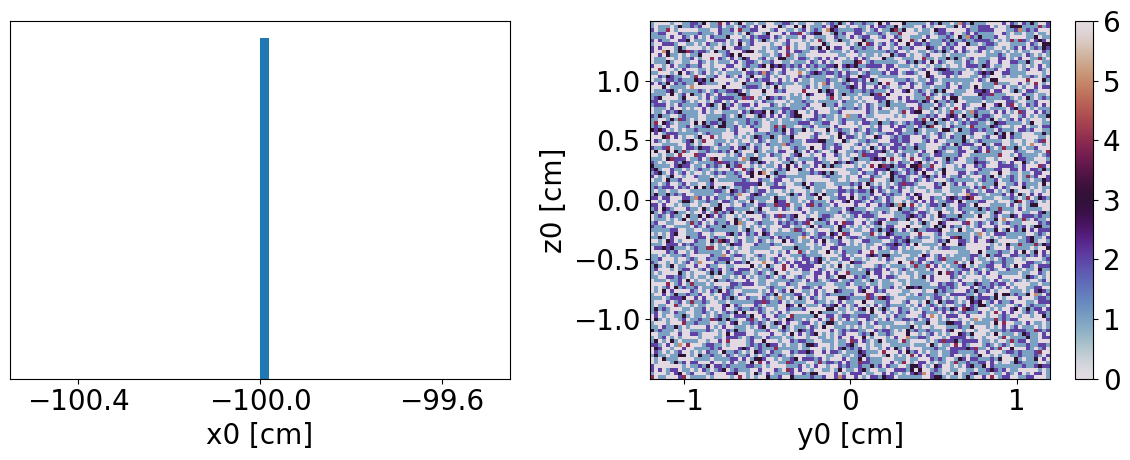

In [10]:
# plots
plt.figure(figsize=(12,5))
#plt.title('Starting point p0 of the neutrons');
plt.subplot(1,2,1)
plt.hist(p0[:,0], bins=50)
plt.xlabel('x0 [cm]')
plt.yticks([])
plt.xticks([-100.4, -100, -99.6])
plt.subplot(1,2,2)
plt.hist2d(p0[:,1], p0[:,2], bins=100, cmap='twilight')
plt.xlabel('y0 [cm]')
plt.ylabel('z0 [cm]');
plt.colorbar()
plt.tight_layout()

plt.savefig('./figures4article/p0.png')

In [11]:
# dimensions of the vectors
print('p0:', p0.nbytes/1e6, 'MB')
print('k0:', k0.nbytes/1e6, 'MB')
print('w0:', w0.nbytes/1e6, 'MB')

p0: 0.24 MB
k0: 0.24 MB
w0: 0.08 MB


## First scattering position
Weight update:
$$ w_1 = w_0 (1-T(d_1)) \frac{\mu_s}{\mu_{tot}} $$
And extraction from a truncated exponential:
$$ PDF_{L-B\  trunc} = e^{-\mu_{s}x} \hspace{1cm} \text{with} \hspace{1cm} x = [0,d_1] $$
N.B. : Care must be taken in the case of non convex sample geometries, where voids must be taken into account!

The output of this subsection is therefor
$$ \vec{p_1} \hspace{1cm} \text{and} \hspace{1cm} w_1

In [102]:
##### EXTRACT THE 1ST SCATTERING POSITION #####

# intercept calculation
ts = inter_fromout(p0, k0)
ts = np.nan_to_num(ts)
if geom_type=='convex':
    ts = np.append(ts, np.zeros((N,2)), axis=1)
if geom_type=='concave':
    pass
d1 = (ts[:,1] - ts[:,0]) + (ts[:,3] - ts[:,2])
# weigth update
w1 = w0*(1-T_tot(d1))*(mu_s/mu_tot)
# dtp2 extraction (one for all)
dtp2 = rand_LB(d1)
# generate void vector
void = np.where(dtp2<=(ts[:, 1]-ts[:, 0]), 0, ts[:,2] - ts[:,1])

p1 = line_param(ts[:,0] + dtp2 + void, p0, k0)

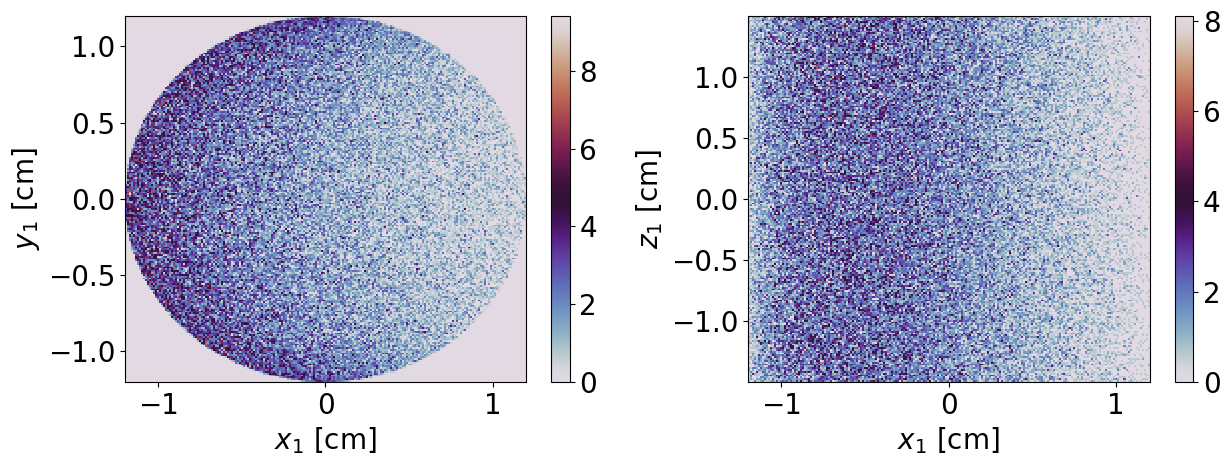

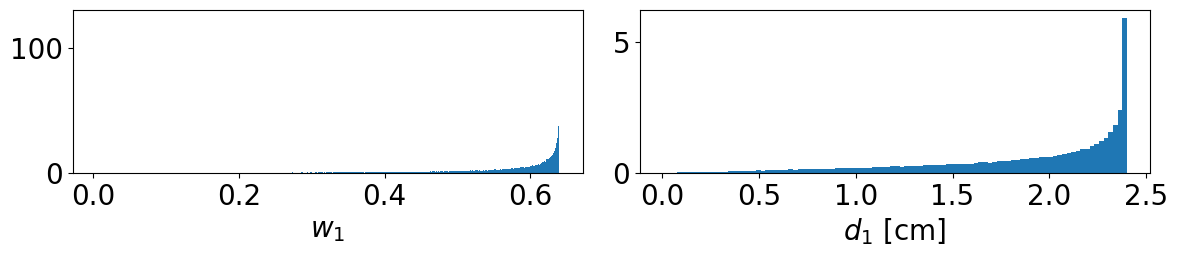

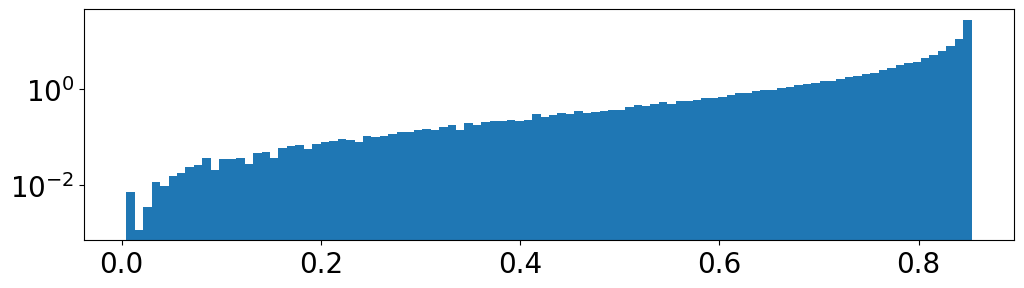

In [103]:
# plots

# heatmap
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.hist2d(p1[:,0], p1[:,1], bins=200, weights=w1, cmap='twilight');
X = np.linspace(0, p1[:,0].max(), 100)
#plt.plot(X, X*np.sin(theta), c='r')
#plt.plot(X, X*np.sin(0), c='r')
plt.xlabel(r'$x_1$ [cm]')
plt.ylabel(r'$y_1$ [cm]')
plt.colorbar()
plt.subplot(1,2,2)
plt.hist2d(p1[:,0], p1[:,2], bins=200, weights=w1, cmap='twilight');
plt.xlabel(r'$x_1$ [cm]')
plt.ylabel(r'$z_1$ [cm]')
plt.tight_layout()
plt.colorbar()

plt.savefig('./figures4article/p1.png')

# 2D
plt.figure(figsize=(12,3))
plt.subplot(1,2,1)
plt.hist(w1, bins=1000, density=True);
plt.xlabel(r'$w_1$')
plt.subplot(1,2,2)
plt.hist(d1, bins=100, density=True);
plt.xlabel(r'$d_1$ [cm]')
plt.tight_layout()

plt.figure(figsize=(12,3))
plt.hist((1-T_tot(d1)), bins=100, density=True);
plt.yscale('log')

## Single scattering path

$$ k_{1s} = k_f * (cos(\theta), sin(\theta), 0) $$
$$ \omega_{1s} = E_i - E_f $$
$$ Q_{1s} = |k_i - k_f|$$
$$ \theta_{1s} = \theta_s

In [104]:
####################################
###### SINGLE SCATTERING PATH ######
####################################

### PROBABILITY OF SINGLE SCATTERING ###
k1s = kf * np.array([np.cos(theta), np.sin(theta), 0]) * np.ones((N, 3))
Q1s = np.linalg.norm(k0 - k1s, axis=1)
omega1s = (Ei - Ef) * np.ones(N)

$$
S^{k_i}_{i,j} =
\left\{ 
    \begin{array}{l}
        S_{i,j} \hspace{.5cm} \text{if} \hspace{.5cm} Q_{lowlim}(k_i,\omega_j) \leq Q_i \leq Q_{uplim}(k_i,\omega_j), \\
        0 \hspace{.5cm} \text{otherwise}
    \end{array} 
\right.
$$

In [105]:
##### Cut of the S(Q,w) for Ei #####
Mij_ki = (Qij>Qlowlimi(ki)) & (Qij<Quplimi(ki)) # mask for ki
Sij_ki = Mij_ki * Sij

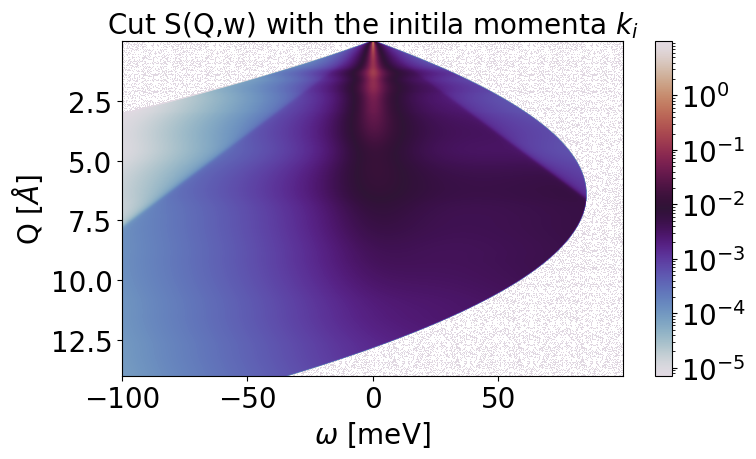

In [106]:
# plot
plt.figure(figsize=(8,5))
plt.title('Cut S(Q,w) with the initila momenta $k_i$')
plt.imshow(Sij_ki, aspect='auto', norm='log', extent=S_imshow_extent, cmap='twilight')
plt.xlabel('$\omega$ [meV]')
plt.ylabel('Q [$\AA$]')
plt.colorbar();
plt.tight_layout()

$$
d\theta_{i,j} = \frac{d\theta}{dQ}(Q_{i},\omega_{j}) dQ_{vec}
$$

In [107]:
##### dthetadQ on the mesh #####
dthetadqij_ki = np.nan_to_num(dthetadq(omegaij, ki, Qij))
dthetadqij_ki[dthetadqij_ki>1e10] = 0

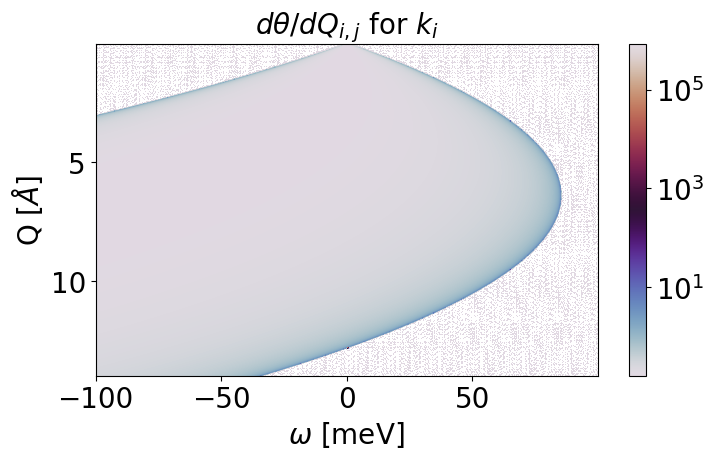

In [108]:
# plot
plt.figure(figsize=(8,5))
plt.title(r'$d\theta /dQ_{i,j}$ for $k_i$')
plt.imshow(dthetadqij_ki, aspect='auto', extent=S_imshow_extent, norm='log', cmap='twilight')
plt.xlabel('$\omega$ [meV]')
plt.ylabel('Q [$\AA$]')
plt.colorbar()
plt.tight_layout()

$$
    P^{k_i}(\theta , \phi , \omega) =  \frac{\sqrt{1-\frac{\omega_j}{E_i}}S^{k_i}_{i,j}}{\text{norm}} d\omega d\Omega_{det} 
$$
with
$$
\text{norm} \simeq 2\pi \sum_i^{N_Q} \sum_j^{N_\omega} \sqrt{1-\frac{\omega_j}{E_i}} S^{k_i}_{i,j} d\omega_j (\frac{d\theta}{dQ})^{k_i}_{i,j} dQ_i \sin\theta_{i,j}^{k_i}
$$

In [109]:
##### S(Q,w) normalization #####
sinthetaij_ki = np.nan_to_num(np.sin(Q2theta(omegaij, ki, Qij)))
norm = 2*np.pi* np.sum(np.nan_to_num(np.sqrt(1-omegaij/Ei)) *  Sij_ki * domegaj * dthetadqij_ki * dQi * sinthetaij_ki)

Pij_ki = np.nan_to_num(np.sqrt(1-omegaij/Ei)) * Sij_ki / norm * domega_det * dOmega_det

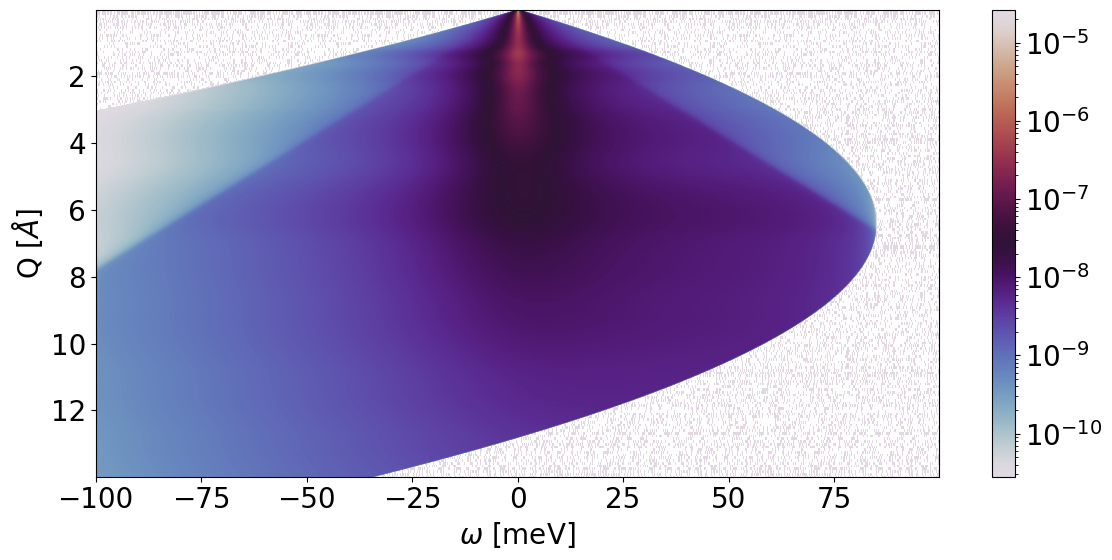

In [110]:
# plot
plt.figure(figsize=(12,6))
#plt.title(r'$P_{i,j}^{k_i}$')
plt.imshow(Pij_ki, aspect='auto', extent=S_imshow_extent, norm='log', cmap='twilight')
plt.xlabel('$\omega$ [meV]')
plt.ylabel('Q [$\AA$]')
plt.colorbar()
plt.tight_layout()

plt.savefig('./figures4article/Pij_ki.png')

Find $i,j$ and update the weights
$$
w_{1s} = w_1 P_{i,j}^{k_i}(\theta_s , \phi=0 , \omega_s)
$$

In [111]:
##### Get the scattering probavilities #####
Q_idx = np.searchsorted(Qi, Q1s)
omega_idx = np.searchsorted(omegaj, omega1s)

w1s = w1 * Pij_ki[Q_idx, omega_idx]

And
$$ w_{fs} = w_{1s} T(d_{2s})$$

In [112]:
##### 1s intercept calculation #####
ts = inter_fromin(p1, k1s)
ts = np.nan_to_num(ts)
if geom_type=='convex':
    ts = np.column_stack([ts, np.zeros((N,2))])
if geom_type=='concave':
    pass

d2s = ts[:,0] + (ts[:,2] - ts[:,1])

##### wfs weigth update #####
wfs = w1s*T_tot(d2s)

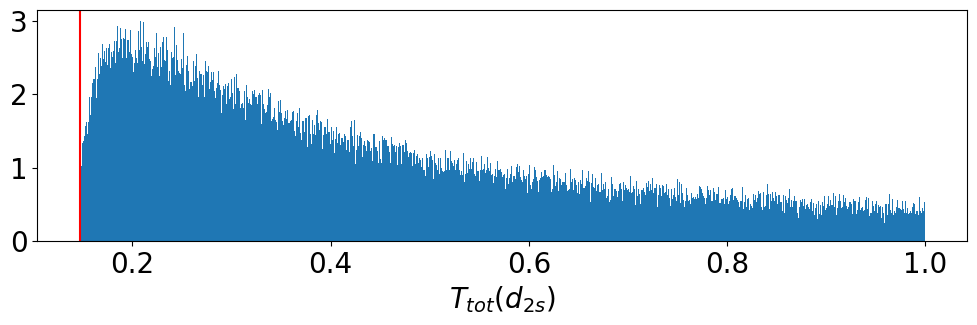

In [113]:
# plot
plt.figure(figsize=(12,3))
plt.hist(T_tot(d2s), bins=1000, density=True);
plt.xlabel(r'$T_{tot}(d_{2s})$')

plt.axvline(T_tot(2.4), c='r')

$$
I_s = \frac{1}{N} \sum_{i=1}^{N} w_{fs}
$$

In [114]:
##### Intensity #####
Is = wfs.mean()
print('Is = ', Is)

Is =  4.239884650635677e-10


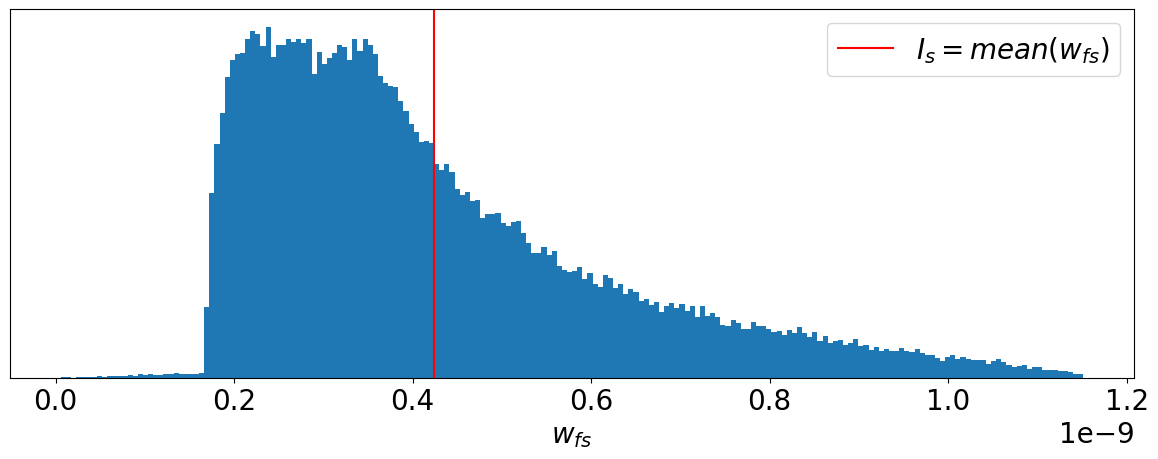

In [115]:
# plot
plt.figure(figsize=(12,5))
plt.hist(wfs, bins=200);
plt.yticks([])
plt.axvline(Is, c='r', label=r'$I_s = mean(w_{fs}$)')
plt.xlabel(r'$w_{fs}$')
plt.legend()
plt.tight_layout()

plt.savefig('./figures4article/wfs.png')

## Multiple scattering path

### Extraction of a scattering direction and energy
$$
W_{i,j}^{k_i} \propto \sqrt{1-\frac{\omega_j}{E_i}}S_{i,j}^{k_i} (\frac{d\theta}{dQ})_{i,j}^{k_i} \sin\theta_{i,j}^{k_i} \hspace{.5cm} \text{with} \hspace{.5cm} \sum_{i,j} W_{i,j} = 1
$$

In [116]:
####################################
##### MULTIPLE SCATTERING PATH #####
####################################

##### EXTRACTION FROM S(q,W) #####

# Probaility mesh for random choiches
Wij_ki = np.nan_to_num(np.sqrt(1-omegaij/Ei)) * Sij_ki * dthetadqij_ki * sinthetaij_ki
Wij_ki /= Wij_ki.sum()

# Random extractions
ij = np.random.choice(np.arange(Wij_ki.size), p=Wij_ki.reshape(-1), size=N)

# Extracted scattering variables
Q1m = Qij.reshape(-1)[ij]
omega1m = omegaij.reshape(-1)[ij]
theta1m = Q2theta(omega1m, ki, Q1m)
E1m = Ei - omega1m
w1m = w1

# Random angle on the scattering cone
phi1m = rand(N)*2*np.pi

# Neutrom momenta after scattering
k1m = (np.array((np.cos(theta1m), np.sin(theta1m)*np.cos(phi1m), np.sin(theta1m)*np.sin(phi1m))) * E2k(E1m)).T
k1m_mod = E2k(E1m)

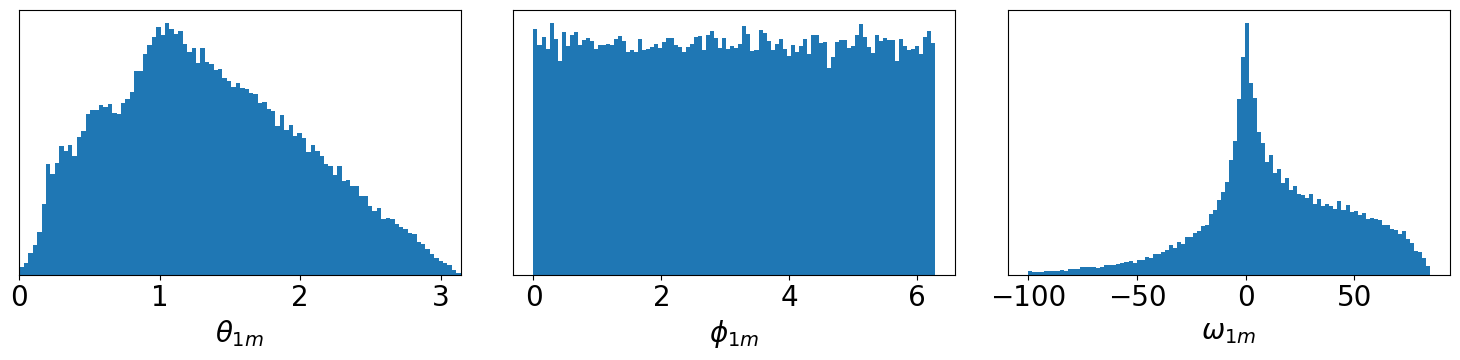

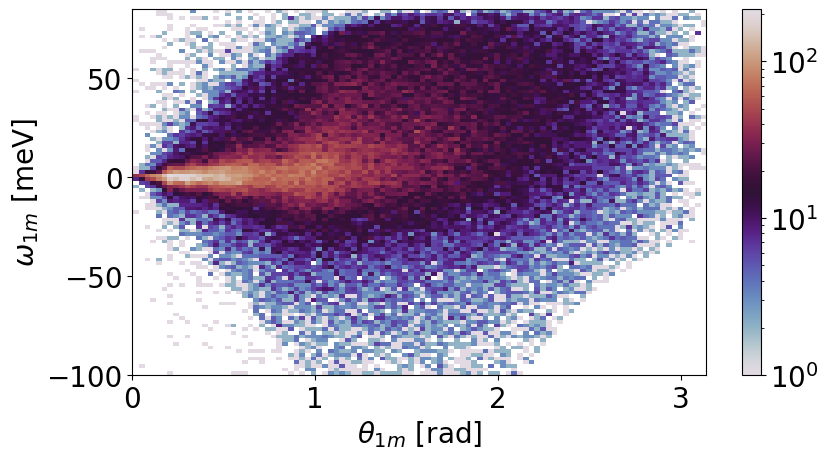

In [117]:
# plot
# 2D
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.hist(theta1m, bins=100, density=True);
plt.yticks([])
plt.xlabel(r'$\theta_{1m}$')
plt.xlim(0, np.pi)
plt.subplot(1,3,2)
plt.hist(phi1m, bins=100, density=True);
plt.yticks([])
plt.xlabel(r'$\phi_{1m}$')
plt.subplot(1,3,3)
plt.hist(omega1m, bins=100, density=True);
plt.yticks([])
plt.xlabel(r'$\omega_{1m}$')
plt.tight_layout()

plt.savefig('./figures4article/event_extraction.png')

# 3D
plt.figure(figsize=(9,5))
plt.hist2d(theta1m, omega1m, bins=100, norm='log', cmap='twilight');
plt.ylabel('$\omega_{1m}$ [meV]')
plt.xlabel(r'$\theta_{1m}$ [rad]')
plt.colorbar()
plt.xlim(0, np.pi)
plt.tight_layout()

plt.savefig('./figures4article/theta1m_omega1m.png')

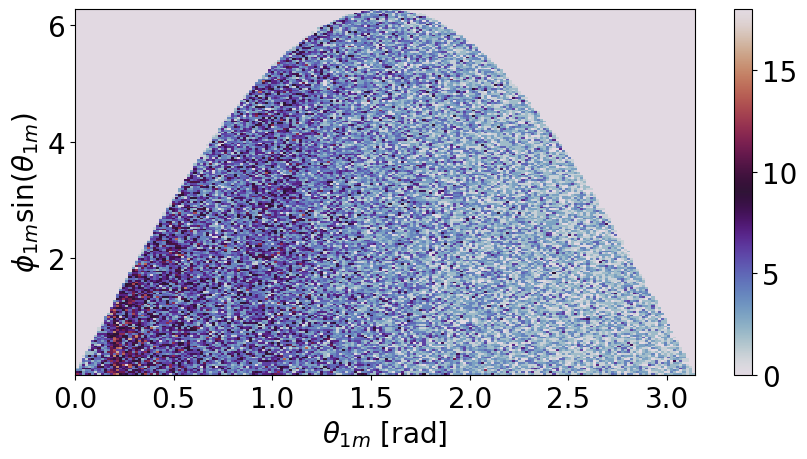

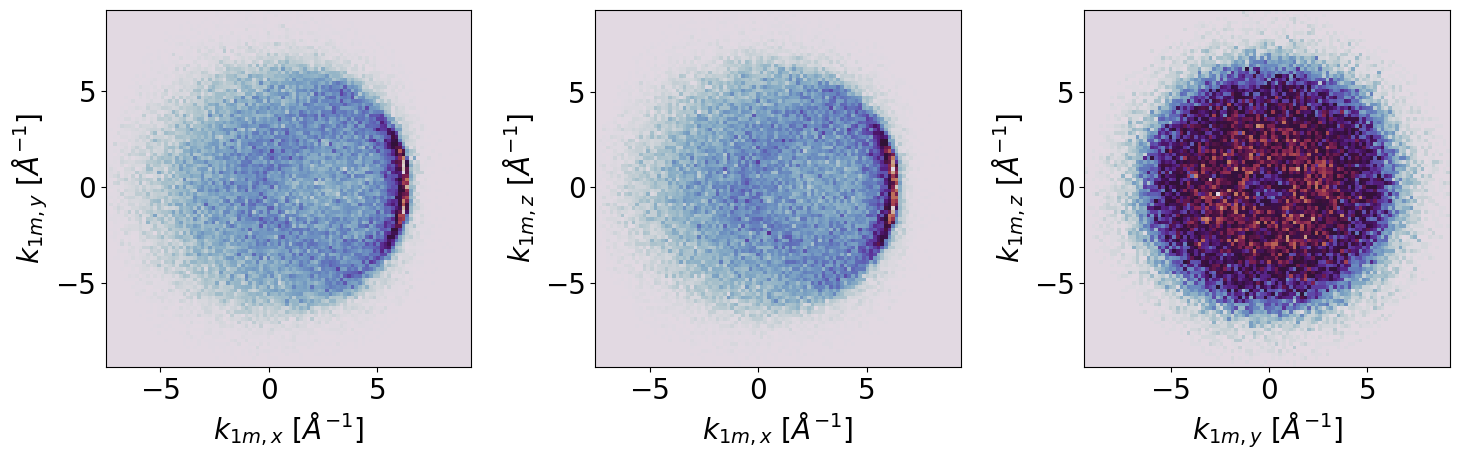

In [118]:
# plot
# heatmap
plt.figure(figsize=(9,5))
plt.hist2d(theta1m, phi1m*np.sin(theta1m), bins=200, cmap = 'twilight');
plt.xlabel(r'$\theta_{1m}$ [rad]')
plt.ylabel(r'$\phi_{1m} \sin(\theta_{1m})$')
plt.colorbar()
plt.xlim(0, np.pi)
plt.tight_layout()

plt.savefig('./figures4article/theta1m.png')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist2d(k1m[:,0], k1m[:,1], bins=100, cmap = 'twilight');
plt.xlabel(r'$k_{1m,x}$ [$\AA^{-1}$]')
plt.ylabel(r'$k_{1m,y}$ [$\AA^{-1}$]')
plt.subplot(1,3,2)
plt.hist2d(k1m[:,0], k1m[:,2], bins=100, cmap = 'twilight');
plt.xlabel(r'$k_{1m,x}$ [$\AA^{-1}$]')
plt.ylabel(r'$k_{1m,z}$ [$\AA^{-1}$]')
plt.subplot(1,3,3)
plt.hist2d(k1m[:,1], k1m[:,2], bins=100, cmap = 'twilight');
plt.xlabel(r'$k_{1m,y}$ [$\AA^{-1}$]')
plt.ylabel(r'$k_{1m,z}$ [$\AA^{-1}$]')
plt.tight_layout()

plt.savefig('./figures4article/k1m.png')

### Extraction of the second scattering position
$$ w_{2m} = w_{1m} (1-T(d_{2m})) \frac{\mu_s}{\mu_{abs}}$$
and extraction from
$$ PDF_{L-B\  trunc} = e^{-\mu_{tot}x} \hspace{1cm} \text{with} \hspace{1cm} x = [0,d_{2m}] $$

In [119]:
##### 1m intercept calculation #####
ts = inter_fromin(p1, k1m)
ts = np.nan_to_num(ts)
if geom_type=='convex':
    ts = np.column_stack([ts, np.zeros((N,2))])
if geom_type=='concave':
    pass

d2m = ts[:,0] + (ts[:,2] - ts[:,1])
w2 = w1m*(1-T_tot(d2m))*mu_s/mu_tot

# position extraction
dtp2 = rand_LB(d2m)
void = np.where(dtp2<=ts[:, 0], 0,ts[:,1] - ts[:,0])
p2 = line_param(dtp2 + void, p1, k1m)

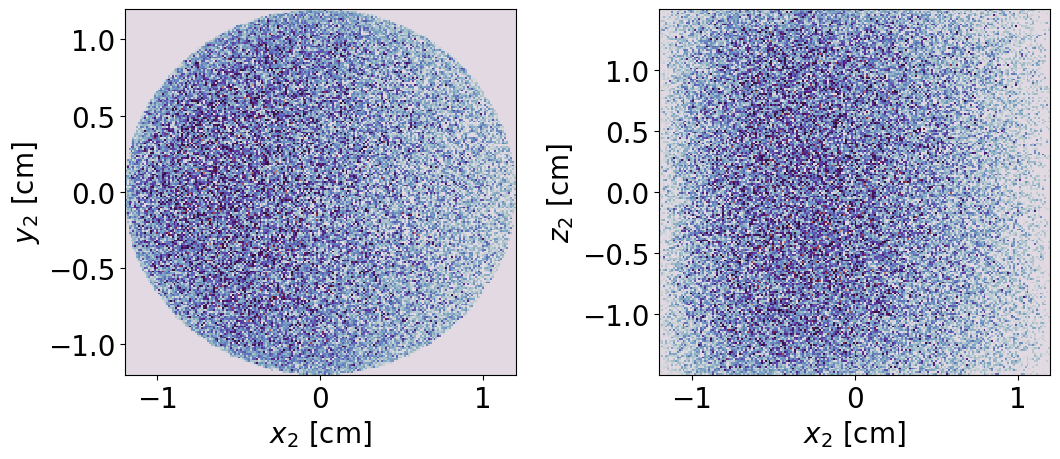

In [120]:
# plot
plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
plt.hist2d(p2[:,0], p2[:,1], bins=200, weights=w2, cmap='twilight');
plt.xlabel(r'$x_2$ [cm]')
plt.ylabel(r'$y_2$ [cm]')
plt.subplot(1,2,2)
plt.hist2d(p2[:,0], p2[:,2], bins=200, weights=w2, cmap='twilight');
plt.xlabel(r'$x_2$ [cm]')
plt.ylabel(r'$z_2$ [cm]')
plt.tight_layout()

plt.savefig('./figures4article/p2.png')

### Probability of the 2 $^{nd}$ scattering event being detectable
We first find $k_{2m}$ and $\omega_{2m}$ imposing the collimator (detector) angle:
$$
\begin{array}{l}
    \textbf{k}_{2m} = k_f * (\cos(\theta), \sin(\theta), 0) \\
    \omega_{2m} = E_{1m} - E_f \\
\end{array}
$$
$$
\begin{array}{l}
    Q_{2m} = |\textbf{k}_{1m} - \textbf{k}_f| \\
    \theta_{2m} = \theta(k_{1m}, Q_{2m})
\end{array}
$$

In [121]:
##### Find k2m, omega2m, Q2m imposing collimator angle #####
k2m = kf * np.array([np.cos(theta), np.sin(theta), 0]) * np.ones((N, 3))
omega2m = (E1m - Ef) * np.ones(N)
Q2m = np.linalg.norm(k1m - k2m, axis=1)
theta2m = Q2theta(omega2m, E2k(E1m), Q2m)

MINOR CORRECTION: we should eliminate (mask) events outside of our $S(Q, \omega)$ mesh. This is later done by setting the weight to 0 if the event is outside the mesh.

In [122]:
### Mask of impossible events
M2mij = ~((Q2m>Qi.max()) | (Q2m<Qi.min()) | (omega2m>omegaj.max()) | (omega2m<omegaj.min()) | np.isnan(theta2m))

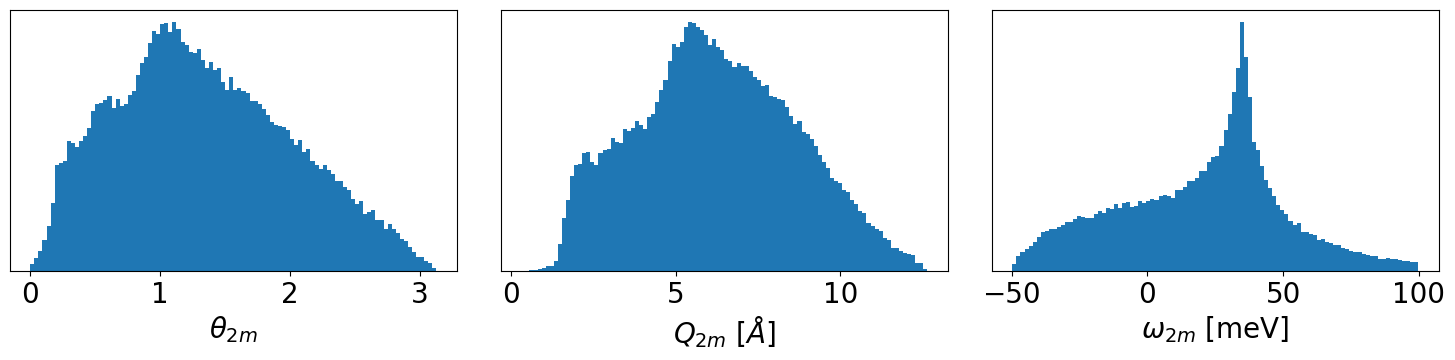

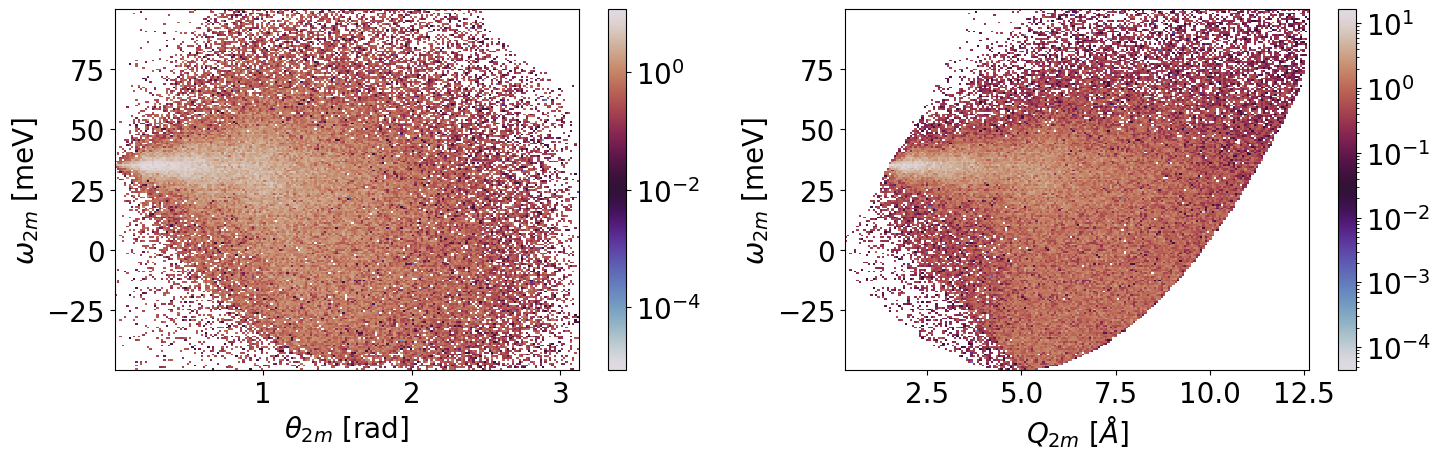

In [123]:
# plot
# 1D
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.hist(theta2m[M2mij], bins=100, density=True);
plt.yticks([])
plt.xlabel(r'$\theta_{2m}$')
plt.subplot(1,3,2)
plt.hist(Q2m[M2mij], bins=100, density=True);
plt.yticks([])
plt.xlabel(r'$Q_{2m}$ [$\AA$]')
plt.subplot(1,3,3)
plt.hist(omega2m[M2mij], bins=100, density=True);
plt.yticks([])
plt.xlabel(r'$\omega_{2m}$ [meV]')

plt.tight_layout()

# 2D
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.hist2d(theta2m[M2mij], omega2m[M2mij], bins=200, norm='log', weights=w2[M2mij], cmap='twilight');
plt.ylabel(r'$\omega_{2m}$ [meV]')
plt.xlabel(r'$\theta_{2m}$ [rad]')
plt.colorbar()

plt.subplot(1,2,2)
plt.hist2d(Q2m[M2mij], omega2m[M2mij], bins=200, norm='log', weights=w2[M2mij], cmap='twilight');
plt.ylabel(r'$\omega_{2m}$ [meV]')
plt.xlabel(r'$Q_{2m}$ [$\AA$]')
plt.tight_layout()
plt.colorbar()

Divide the energies $E_{1m}$ in $B$ bunches of width $dE = \text{max}(E_{1m})/B$. The approximated energy of the $l^{\text{th}}$ bunch is $E_l=dE*(l-\frac{1}{2})$. For each neutron in the bunch $l$, that is, for each neutron with $E_{1m}\in [E_l-dE/2, E_l+dE/2]$, the probability of being scattered towards the detector with the correct energy is
$$
    P^l(\theta_{2m}, \phi, \omega_{2m})  =  \frac{\sqrt{1-\frac{\omega_j}{E_i}}S^{k_l}_{i,j}}{\text{norm}} d\omega_{det} d\Omega_{det}
$$
with
$$
    \text{norm} \simeq 2\pi \sum_i^{N_Q} \sum_j^{N_\omega} \sqrt{1-\frac{\omega_j}{E_i}} S^{k_l}_{i,j} d\omega_j (\frac{d\theta}{dQ})_{i,j}^{k_l} dQ_{i} \sin\theta_{i,j}^{k_l}
$$

In [124]:
##### 2nd EVENT SCATTERING PROBABILITIES #####

# Bunching the initial energies E1m
E_min = E1m[M2mij].min()
E_max = E1m[M2mij].max()
E_ranges = np.linspace(E_min, E_max, B)[1:]
dbunch = (E_ranges[1]-E_ranges[0])

# find the bunch indexes
bunch_idx = np.searchsorted(E_ranges, E1m, side='left')
bunch_idx[~M2mij] = -1 # putting impossible events with idx=-1, i.e. in the next part P stay 0

# indexing Q2m and omega2m on the mesh
Q_idx = np.searchsorted(Qi, Q2m)
omega_idx = np.searchsorted(omegaj, omega2m)

# calculating probabilities at bunches
P = np.zeros(N)

for b in range(B-1):

    E_b = E_ranges[b]-dbunch/2
    k_b = E2k(E_b)

    Mij_b = ((Qij>Qlowlimi(k_b)) & (Qij<Quplimi(k_b)))
    Sij_b = Mij_b * Sij
    sinthetaij_b = np.nan_to_num(np.sin(Q2theta(omegaij, k_b, Qij)))
    dthetadqij_b = np.nan_to_num(dthetadq(omegaij, k_b, Qij)) * Mij_b
    
    norm = 2*np.pi*np.sum(np.nan_to_num(np.sqrt(1 - omegaij/E_b))*Sij_b * domegaj * dthetadqij_b * dQi * sinthetaij_b)

    i = Q_idx[bunch_idx==b]
    j = omega_idx[bunch_idx==b]
    ij = Q_idx[bunch_idx==b], omega_idx[bunch_idx==b]

    P[bunch_idx==b] = np.nan_to_num(np.sqrt(1 - omegaij[ij]/E_b))*Sij_b[ij]/norm * domega_det * dOmega_det

w2m = w2 * P

In [ ]:
##### S(Q,w) normalization #####
sinthetaij_ki = np.nan_to_num(np.sin(Q2theta(omegaij, ki, Qij)))
norm = 2*np.pi* np.sum(np.nan_to_num(np.sqrt(1-omegaij/Ei)) *  Sij_ki * domegaj * dthetadqij_ki * dQi * sinthetaij_ki)

Pij_ki = np.nan_to_num(np.sqrt(1-omegaij/Ei)) * Sij_ki / norm * domega_det * dOmega_det

### Trasmission of second event to the detector
$$ w_{fm} = w_{2m} T(d_{3m}) $$


In [125]:
##### LAST INTERCEPT TRASMISSION #####
ts = inter_fromin(p1, k2m)
ts = np.nan_to_num(ts)
if geom_type=='convex':
    ts = np.column_stack([ts, np.zeros((N,2))])
if geom_type=='concave':
    pass

d3m = ts[:,0] + (ts[:,2] - ts[:,1])
wfm = w2m*T_tot(d3m)

and
$$ I_m = \frac{1}{N} \sum_{i=1}^{N} w_{fm} $$

In [126]:
Im = wfm.mean()

print('Im : {:0.2e}'.format(Im))
print('Im/Is = {:0.2f}'.format(Im/Is))

Im : 8.33e-10
Im/Is = 1.96


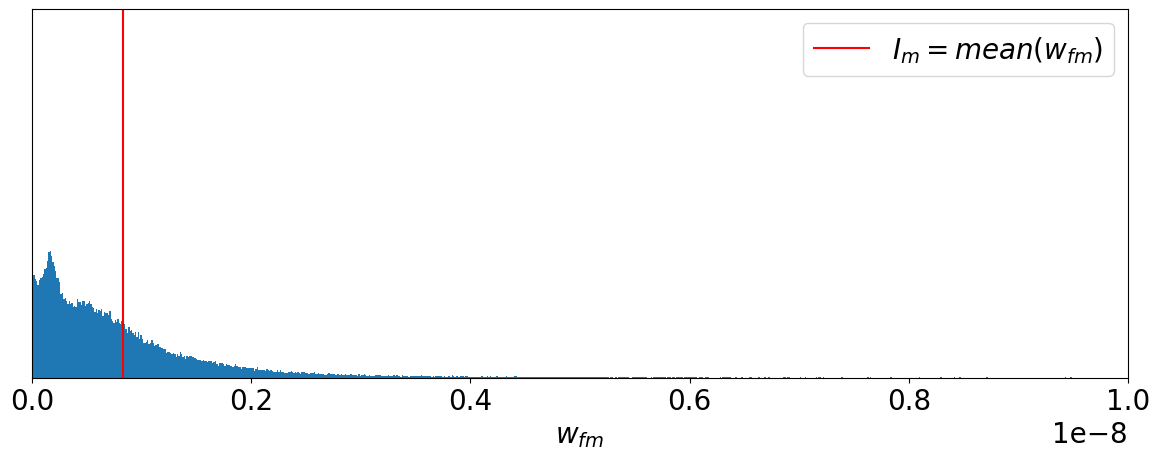

In [127]:
# plot
plt.figure(figsize=(12,5))
plt.hist(wfm, bins=3000);
plt.yticks([])
plt.axvline(Im, c='r', label=r'$I_m = mean(w_{fm}$)')
plt.xlabel(r'$w_{fm}$')
plt.legend()
plt.xlim(0,1e-8)
plt.tight_layout()

plt.savefig('./figures4article/wfm.png')

## Let's see what happend

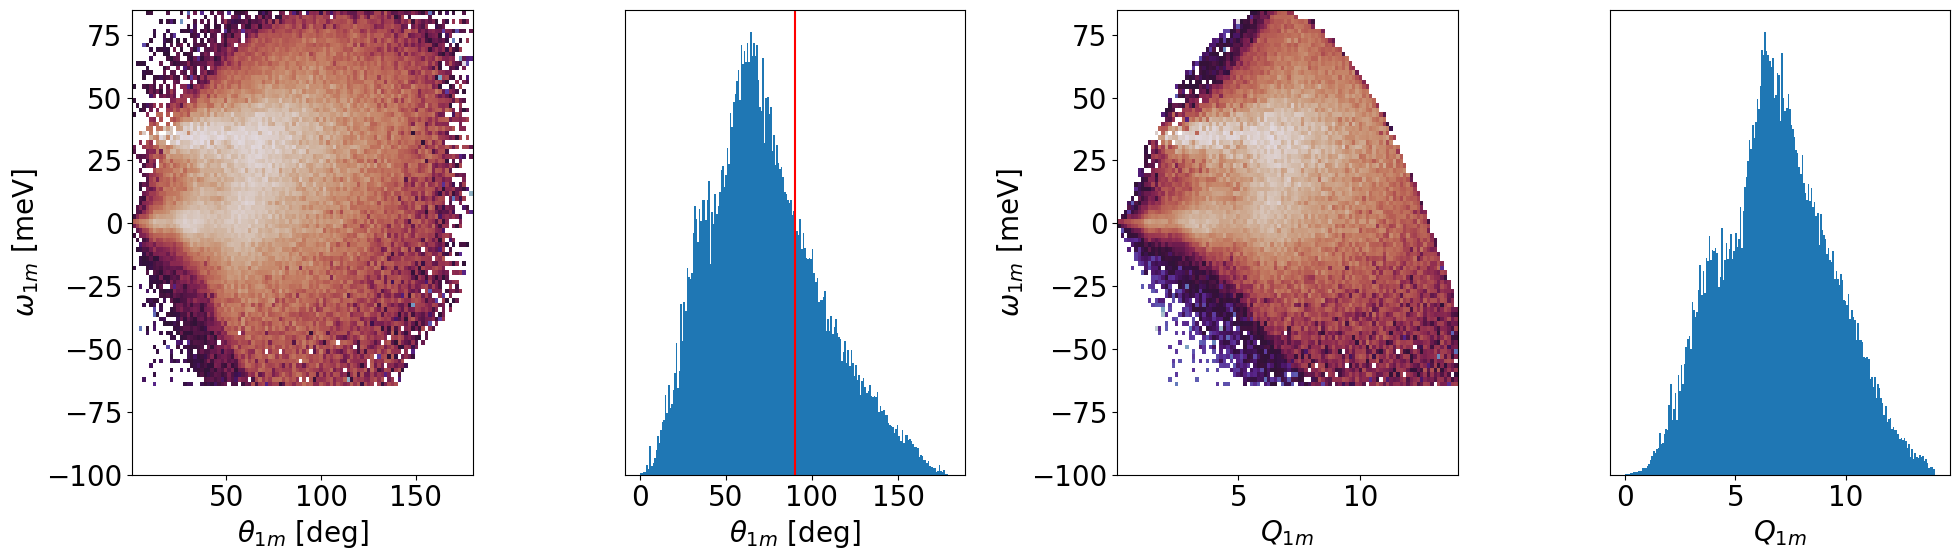

In [128]:
# heatmap
plt.figure(figsize=(20,6))
plt.subplot(1,4,1)
plt.hist2d(np.rad2deg(theta1m), omega1m, bins=100, weights=wfm, norm='log',  cmap='twilight');
plt.xlabel(r'$\theta_{1m}$ [deg]')
plt.ylabel('$\omega_{1m}$ [meV]')

plt.subplot(1,4,2)
plt.hist(np.rad2deg(theta1m), bins=200, weights=wfm);
plt.yticks([])
plt.axvline(90, c='r')
plt.xlabel(r'$\theta_{1m}$ [deg]')

plt.subplot(1,4,3)
plt.hist2d(Q1m, omega1m, bins=100, weights=wfm, norm='log',  cmap='twilight');
plt.xlabel(r'$Q_{1m}$')
plt.ylabel('$\omega_{1m}$ [meV]')

plt.subplot(1,4,4)
plt.hist(Q1m, bins=200, weights=wfm);
plt.yticks([]) 
plt.xlabel(r'$Q_{1m}$')

plt.tight_layout()

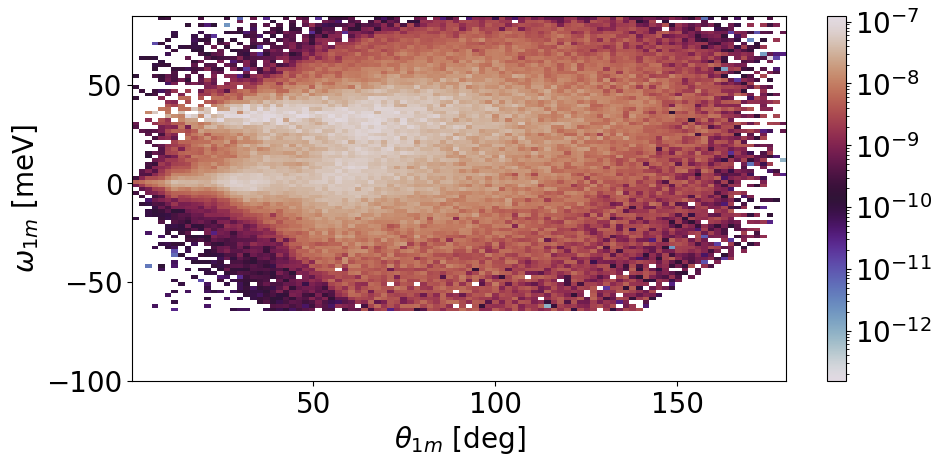

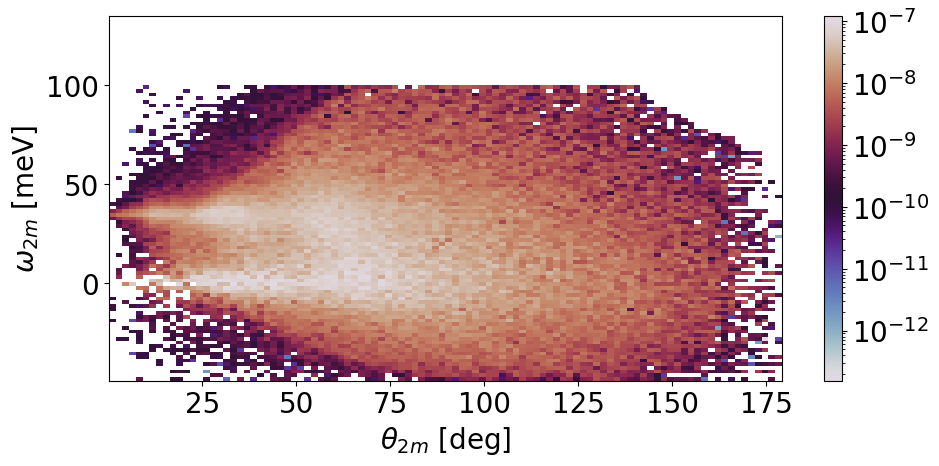

In [129]:
# heatmap
plt.figure(figsize=(10,5))
plt.hist2d(np.rad2deg(theta1m), omega1m, bins=100, weights=wfm, norm='log', cmap='twilight');
plt.xlabel(r'$\theta_{1m}$ [deg]')
plt.ylabel('$\omega_{1m}$ [meV]')
plt.tight_layout()
#plt.ylim(-60, 80)
plt.colorbar()

# heatmap
plt.figure(figsize=(10,5))
plt.hist2d(np.rad2deg(theta2m), omega2m, bins=100, weights=wfm, norm='log', cmap='twilight');
plt.xlabel(r'$\theta_{2m}$ [deg]')
plt.ylabel('$\omega_{2m}$ [meV]')
plt.tight_layout()
#plt.ylim(-60, 80)
plt.colorbar()


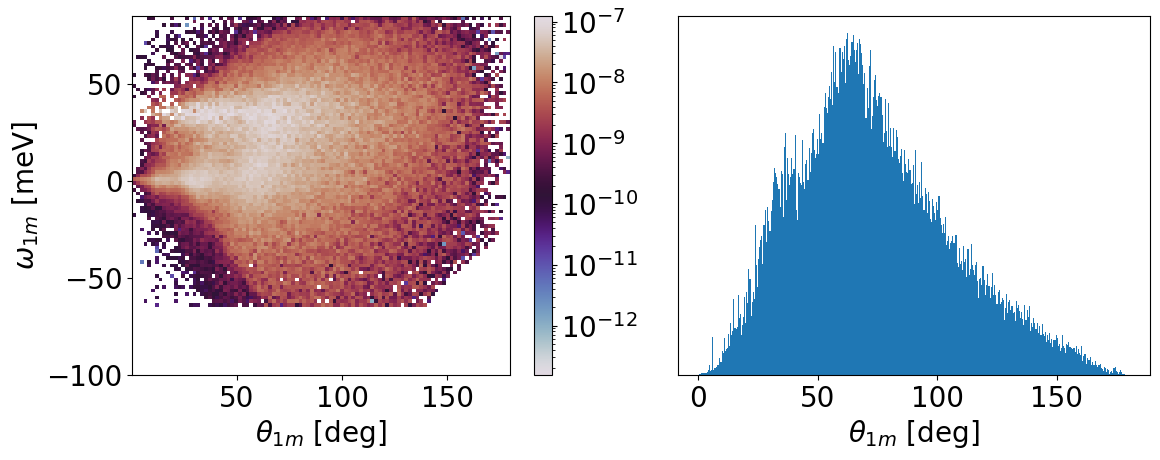

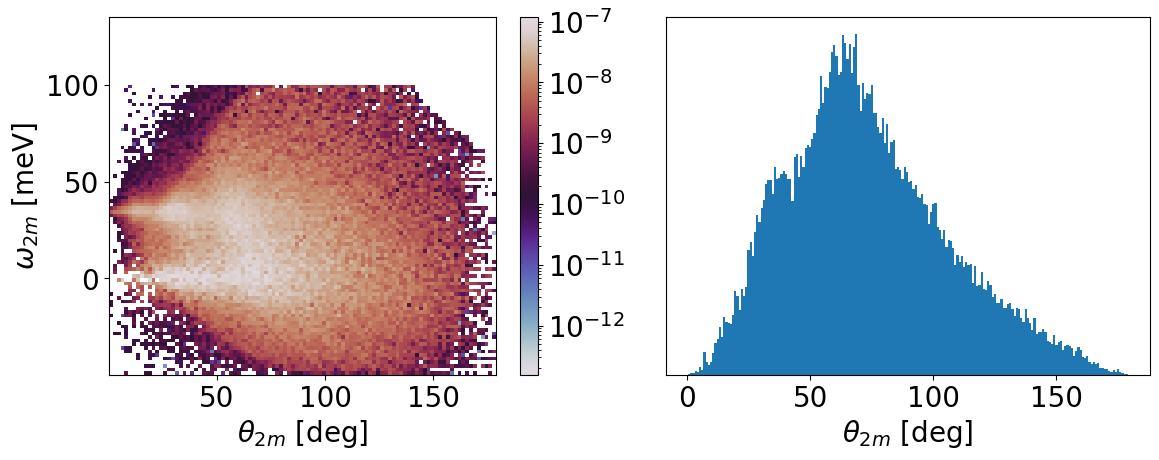

In [130]:
# heatmap
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist2d(np.rad2deg(theta1m), omega1m, bins=100, weights=wfm, norm='log', cmap='twilight');
plt.xlabel(r'$\theta_{1m}$ [deg]')
plt.ylabel('$\omega_{1m}$ [meV]')

plt.subplot(1,2,2)
plt.hist(np.rad2deg(theta1m), bins=400, weights=wfm);
#plt.axvline(90, c='r')
plt.xlabel(r'$\theta_{1m}$ [deg]')
plt.yticks([])
plt.colorbar()
plt.tight_layout()

plt.savefig('./figures4article/theta1m_omega1m_final.png')

# heatmap
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist2d(np.rad2deg(theta2m), omega2m, bins=100, weights=wfm, norm='log', cmap='twilight');
plt.colorbar()
plt.xlabel(r'$\theta_{2m}$ [deg]')
plt.ylabel('$\omega_{2m}$ [meV]')

plt.subplot(1,2,2)
plt.hist(np.rad2deg(theta2m), bins=200, weights=wfm);
#plt.axvline(90, c='r')
plt.xlabel(r'$\theta_{2m}$ [deg]')
plt.yticks([])
plt.tight_layout()

plt.savefig('./figures4article/theta2m_omega2m_final.png')